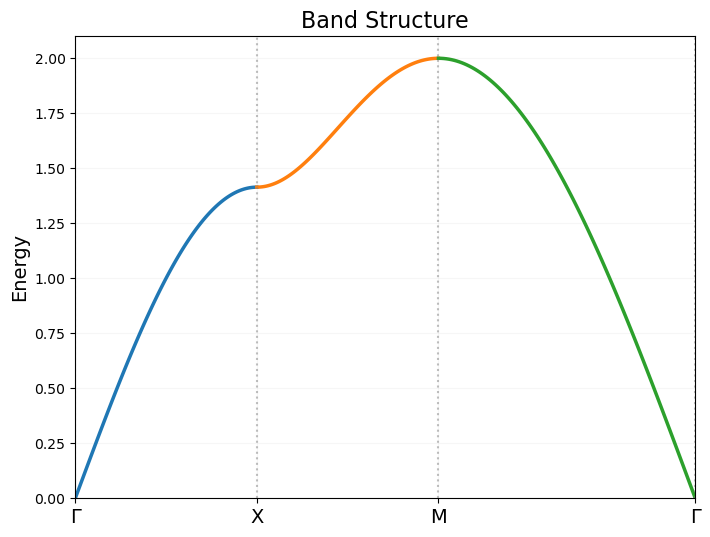

In [28]:
import numpy as np
import matplotlib.pyplot as plt

def get_energy(k_vecs):
    """
    The energy equation for the s-band.
    """
    kx, ky, kz = k_vecs[:, 0], k_vecs[:, 1], k_vecs[:, 2]
    
    # Equation
    E = np.sqrt(2-np.cos(kx)-np.cos(ky))
    
    return E

def plot_k_length_bands():
    # 1. Define Coordinates of High Symmetry Points
    points = {
        'X': np.array([-np.pi, 0, 0]),
        'Γ': np.array([0, 0, 0]), 
        'L': np.array([np.pi, np.pi, np.pi]), 
        'M': np.array([-np.pi, -np.pi, 0])
    }

    # 2. Define the Sequence of points
    # You can add more points here if defined in the dictionary above
    path_labels = ['Γ', 'X', 'M']
    path_labels.append(path_labels[0])
    
    # Setup Plot
    plt.figure(figsize=(8, 6))
    
    # Variable to track cumulative distance (starts at 0)
    current_dist = 0.0
    
    # Lists to store where to put the labels (X, G, L) on the x-axis
    tick_locs = [0.0]
    tick_labels = [path_labels[0]]

    # --- LOOP THROUGH SEGMENTS ---
    for i in range(len(path_labels) - 1):
        
        # A. Identify start and end for this segment
        label_start = path_labels[i]
        label_end   = path_labels[i+1]
        
        k_start = points[label_start]
        k_end   = points[label_end]
        
        # B. Calculate REAL Euclidean distance (k-vector length)
        dist = np.linalg.norm(k_end - k_start)
        
        # C. Generate the linear interpolation arrays
        num_points = 100
        t = np.linspace(0, 1, num_points)
        
        # Calculate 3D K-vectors
        k_path = k_start + (k_end - k_start) * t[:, None]
        
        # Calculate X-axis positions based on cumulative distance
        # We start at current_dist and go to current_dist + dist
        x_axis = np.linspace(current_dist, current_dist + dist, num_points)
        
        # D. Calculate Energy
        energies = get_energy(k_path)
        
        # E. Plot
        plt.plot(x_axis, energies, linewidth=2.5, label=f"{label_start}-{label_end}")
        
        # F. Update the tracker for the next loop
        current_dist += dist
        
        # Store tick location
        tick_locs.append(current_dist)
        tick_labels.append(label_end)
        
    # --- FORMATTING ---
    
    # Add vertical lines at the tick locations
    for x in tick_locs:
        plt.axvline(x=x, color='gray', linestyle=':', alpha=0.5)
        
    plt.xticks(tick_locs, tick_labels, fontsize=14)
    
    plt.ylabel(r'Energy', fontsize=14)
    plt.title('Band Structure', fontsize=16)
    plt.xlim(0, current_dist)
    plt.ylim(bottom=0)
    plt.grid(True, alpha=0.1)
    
    plt.show()

if __name__ == "__main__":
    plot_k_length_bands()